In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Accéder à votre dataset
import pandas as pd
dataset_path = '/content/drive/MyDrive/ADSP/Resume.csv'
df = pd.read_csv(dataset_path)
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [8]:
!pip install datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.6/221.6 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 33.2 MB/s eta 0:00:00


In [9]:
from datasets import load_dataset
import pandas as pd

jobs_ds = load_dataset("AzharAli05/Resume-Screening-Dataset", split="train")

# Convertir en DataFrame pandas
jobs = pd.DataFrame(jobs_ds)
print(jobs.shape)
jobs.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10174 [00:00<?, ? examples/s]

(10174, 5)


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...


resume.csv cleaning

In [10]:
# Mean length of content in characters
df.Resume_str.drop_duplicates().apply(len).mean()

np.float64(6296.17929089444)

In [11]:
# display the different article categories
df.Category.drop_duplicates().tolist()

['HR',
 'DESIGNER',
 'INFORMATION-TECHNOLOGY',
 'TEACHER',
 'ADVOCATE',
 'BUSINESS-DEVELOPMENT',
 'HEALTHCARE',
 'FITNESS',
 'AGRICULTURE',
 'BPO',
 'SALES',
 'CONSULTANT',
 'DIGITAL-MEDIA',
 'AUTOMOBILE',
 'CHEF',
 'FINANCE',
 'APPAREL',
 'ENGINEERING',
 'ACCOUNTANT',
 'CONSTRUCTION',
 'PUBLIC-RELATIONS',
 'BANKING',
 'ARTS',
 'AVIATION']

In [12]:
# We check the number of article per category
df.drop_duplicates().groupby(df.Category).size()

,0
Category,
ACCOUNTANT,118
ADVOCATE,118
AGRICULTURE,63
APPAREL,97
ARTS,103
AUTOMOBILE,36
AVIATION,117
BANKING,115
BPO,22


In [26]:
# === 1️⃣ MODULE ATS : Extraction et scoring des CV ===

import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

def extract_keywords(text):

    if not isinstance(text, str):
        return []
    text = re.sub(r"[^a-zA-Z\s]", " ", text.lower())
    tokens = [w for w in text.split() if len(w) > 2]
    return tokens


def ats_score(cv_text, job_text):
    """
    Calcule un score de correspondance ATS simple basé sur les mots-clés communs.
    """
    cv_kw = set(extract_keywords(cv_text))
    job_kw = set(extract_keywords(job_text))
    if not job_kw:
        return 0
    overlap = cv_kw.intersection(job_kw)
    score = len(overlap) / len(job_kw)
    return round(score * 100, 2)


# Application du scoring ATS à tous les couples (CV, Job)
def compute_ats_scores(resumes_df, jobs_df):
    scores = []
    for _, job in jobs_df.iterrows():
        job_text = job["Job_Description"]
        job_role = job["Role"]
        print(f"\n🧩 Scoring ATS pour le poste : {job_role}")
        job_scores = []
        for i, cv in enumerate(resumes_df["Resume_str"]):
            score = ats_score(cv, job_text)
            job_scores.append(score)
        scores.append(job_scores)
    return pd.DataFrame(scores, index=jobs_df["Role"], columns=resumes_df.index)

# === Exécution ===
ats_matrix = compute_ats_scores(df, jobs)

print("✅ Scores ATS calculés avec succès !")
display(ats_matrix.head())


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : Product Manager

🧩 Scoring ATS pour le poste : Software Engineer

🧩 Scoring ATS pour le poste : Product Manager

🧩 Scoring ATS pour le poste : UI Engineer

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : Software Engineer

🧩 Scoring ATS pour le poste : Data Engineer

🧩 Scoring ATS pour le poste : Software Engineer

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : UI Engineer

🧩 Scoring ATS pour le poste : Data Scientist

🧩 Scoring ATS pour le poste : Data Engineer

🧩 Scoring ATS pour le poste : Software Engineer

🧩 Scoring ATS pour le poste : Data Engineer

🧩 Scoring ATS pour le poste : Software Engineer

🧩 Scoring ATS pour le poste : Product Manager

🧩 Scoring ATS pour le poste : Software

KeyboardInterrupt: 

In [13]:
# Nettoyage des données
print("Valeurs manquantes avant nettoyage:")
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

Valeurs manquantes avant nettoyage:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [14]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer
from tqdm.notebook import tqdm

# Télécharger les ressources nécessaires
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Exemple de fonction de nettoyage
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokenizer = TreebankWordTokenizer()
    tokens = tokenizer.tokenize(text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Application au dataframe
df['Resume_clean'] = df['Resume_str'].apply(clean_text)

print("✅ Nettoyage des CV effectué avec succès !")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Nettoyage des CV effectué avec succès !


In [15]:
from nltk.tokenize import TreebankWordTokenizer
from nltk.tokenize import ToktokTokenizer
from nltk.tokenize import TweetTokenizer
from tqdm.notebook import tqdm

tokenizers = [TreebankWordTokenizer(), ToktokTokenizer(), TweetTokenizer()]
import pdb # python debugger
for tok in tqdm(tokenizers):
  print('Using tokenizer: %s' % (tok))
  arr = df.Resume_str.drop_duplicates().apply(lambda x: tok.tokenize(x)).array
  # We flatten the list.
  arr = [ x for X in arr for x in X]
  # the set object transforms a list to the set of unique elements in the list :
  print('The 30 first tokens: %s' % (arr[:30]) )
  print("Vocabulary size: {0} with {1} tokenizer".format(len(set(arr)), tok))
  print('='*5)

  0%|          | 0/3 [00:00<?, ?it/s]

Using tokenizer: <nltk.tokenize.treebank.TreebankWordTokenizer object at 0x7db458ac5670>
The 30 first tokens: ['HR', 'ADMINISTRATOR/MARKETING', 'ASSOCIATE', 'HR', 'ADMINISTRATOR', 'Summary', 'Dedicated', 'Customer', 'Service', 'Manager', 'with', '15+', 'years', 'of', 'experience', 'in', 'Hospitality', 'and', 'Customer', 'Service', 'Management.', 'Respected', 'builder', 'and', 'leader', 'of', 'customer-focused', 'teams', ';', 'strives']
Vocabulary size: 82252 with <nltk.tokenize.treebank.TreebankWordTokenizer object at 0x7db458ac5670> tokenizer
=====
Using tokenizer: <nltk.tokenize.toktok.ToktokTokenizer object at 0x7db435ba9100>
The 30 first tokens: ['HR', 'ADMINISTRATOR/MARKETING', 'ASSOCIATE', 'HR', 'ADMINISTRATOR', 'Summary', 'Dedicated', 'Customer', 'Service', 'Manager', 'with', '15+', 'years', 'of', 'experience', 'in', 'Hospitality', 'and', 'Customer', 'Service', 'Management.', 'Respected', 'builder', 'and', 'leader', 'of', 'customer-focused', 'teams', ';', 'strives']
Vocabulary s

  0%|          | 0/3 [00:00<?, ?it/s]

Counter({',': 186009, 'and': 122400, 'to': 53572, 'of': 42637, 'the': 35486, 'for': 28139, 'in': 27096, 'with': 21490, 'a': 15626, 'State': 15316, 'City': 14930, 'Company': 11886, 'Name': 11645, ':': 10847, 'as': 10065, 'on': 9991, ')': 9407, '(': 9264, 'all': 8467, '－': 6890, 'by': 6708, 'management': 6265, 'customer': 5951, '-': 5665, '&': 5522, 'new': 5456, 'sales': 5254, "'s": 5112, 'Management': 4868, ';': 4770, 'I': 4466, 'that': 4433, 'team': 4243, 'business': 4114, 'including': 3996, 'or': 3988, 'from': 3950, 'service': 3794, 'at': 3710, 'training': 3544, 'development': 3503, 'skills': 3482, 'Skills': 3464, 'Education': 3293, 'work': 3233, 'University': 3081, 'Business': 3061, 'financial': 3053, 'support': 3021, 'an': 3011, 'Manager': 2998, 'staff': 2903, 'Experience': 2859, 'company': 2832, 'project': 2828, 'Microsoft': 2784, 'customers': 2758, 'marketing': 2727, 'other': 2693, 'data': 2664, '.': 2555, 'through': 2546, 'clients': 2543, '%': 2533, 'client': 2488, 'reports': 242

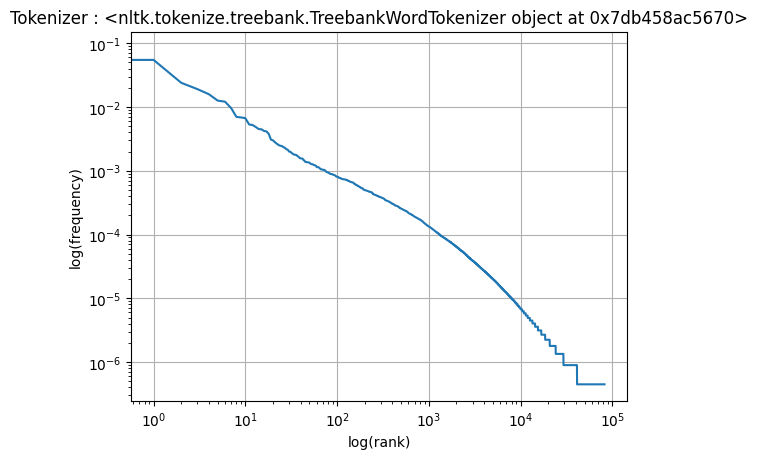

Counter({',': 185996, 'and': 122402, 'to': 53572, 'of': 42637, 'the': 35485, 'for': 28139, 'in': 27098, 'with': 21490, 'a': 15625, 'State': 15316, 'City': 14930, 'Company': 11885, 'Name': 11645, ':': 10812, 'as': 10065, 'on': 9991, ')': 9407, '(': 9264, 'all': 8467, '&#9;': 7257, "'": 7129, '－': 6890, 'by': 6708, 'management': 6263, 'customer': 5958, '-': 5657, 'new': 5455, 's': 5262, 'sales': 5253, 'Management': 4868, ';': 4770, '&amp;': 4745, 'I': 4450, 'that': 4433, 'team': 4245, 'business': 4114, 'including': 3996, 'or': 3993, 'from': 3950, 'service': 3795, 'at': 3710, 'training': 3543, 'development': 3501, 'skills': 3471, 'Skills': 3461, 'Education': 3293, 'work': 3233, 'University': 3078, 'Business': 3062, 'financial': 3053, 'support': 3019, 'an': 3011, 'Manager': 2997, 'staff': 2903, 'Experience': 2859, 'company': 2836, 'project': 2828, 'Microsoft': 2784, 'customers': 2761, 'marketing': 2729, 'other': 2693, 'data': 2664, 'clients': 2546, 'through': 2546, '%': 2533, '"': 2505, 'c

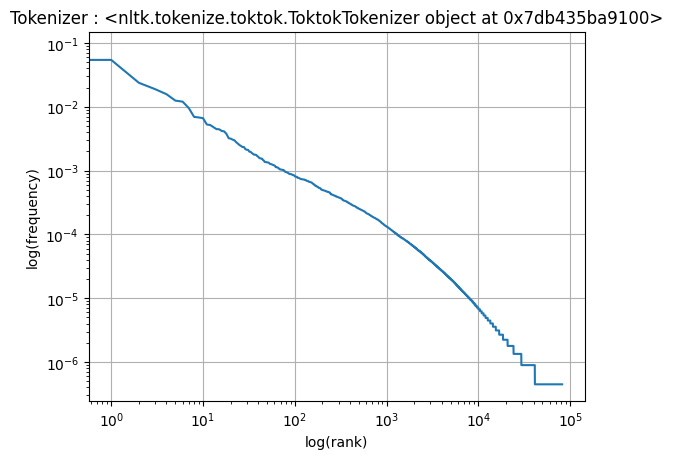

Counter({',': 186149, 'and': 122881, '.': 92151, 'to': 53611, 'of': 42652, 'the': 35502, 'for': 28164, 'in': 27153, 'with': 21517, 'a': 15659, 'State': 15327, 'City': 14934, 'Company': 11885, '/': 11827, 'Name': 11646, ':': 10633, 'as': 10071, 'on': 10033, '(': 9132, ')': 9109, '-': 8720, 'all': 8485, 'management': 6956, '－': 6890, 'by': 6711, 'customer': 5963, 'sales': 5595, '&': 5483, 'new': 5482, 'Management': 5063, ';': 4617, 'team': 4588, 'I': 4554, 'that': 4436, 'or': 4434, 'business': 4402, 'service': 4289, 'skills': 4168, 'including': 4000, 'from': 3956, 'development': 3830, 'training': 3778, 'at': 3715, 'Skills': 3486, 'work': 3421, 'staff': 3387, 'Education': 3350, 'customers': 3343, 'Manager': 3271, 'support': 3208, 'Business': 3145, 'University': 3117, 'financial': 3073, 'an': 3011, 'project': 3006, 'clients': 3000, 'Experience': 2876, 'reports': 2842, 'data': 2834, 'marketing': 2814, 'Microsoft': 2797, 'company': 2774, 'experience': 2716, 'process': 2710, 'other': 2695, 's

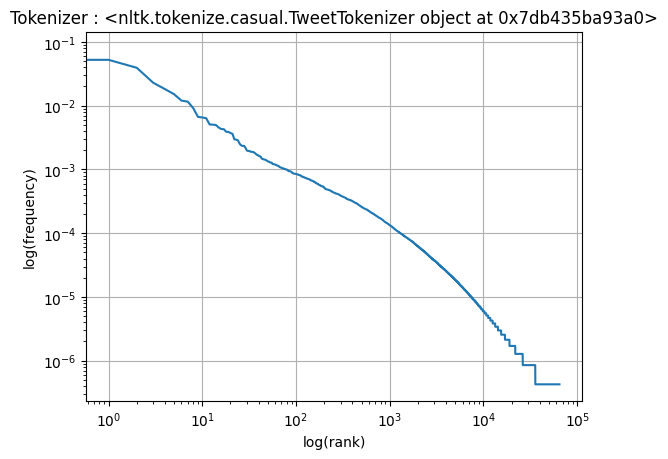

In [16]:
from collections import Counter
import matplotlib.pyplot as plt

for tok in tqdm(tokenizers):
  arr = df.Resume_str.drop_duplicates().apply(lambda x: tok.tokenize(x)).array
  # We flatten the list. We could use this : arr = reduce(add, arr)   but it would take too much time.
  arr = [ x for X in arr for x in X]
  # We use reduce to concatenate all the lists in arr, but we don't use "set"
  # so that we can count occurencies with a Counter object
  c = Counter(arr)
  print(c)
  # Formating the counter object to a proper dataset
  d = pd.DataFrame(c, index=['occurrences']).transpose().reset_index()
  d.columns=['word', 'occurences']
  # Computing frequencies instead of occurences
  nb_total = d.occurences.sum()
  d['freq'] = d.occurences.apply(lambda x: x/nb_total)
  # Sorting by frequency, most frequent word at the top of the df
  d = d.sort_values('freq', ascending=False)
  plt.figure()
  plt.grid()
  plt.xscale('log')  # Using log scale
  plt.yscale('log')  # Using log scale
  plt.xlabel('log(rank)')
  plt.ylabel('log(frequency)')
  plt.title("Tokenizer : {0}".format(tok))
  x = list(range(d.shape[0]))
  plt.plot(x, d.freq)
  plt.show()


job description cleaning
```
# Ce texte est au format code
```



In [17]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # ✅ obligatoire avec la nouvelle version NLTK
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
# === 2️⃣ Vérifier les valeurs manquantes ===
print("\n📊 Nombre de valeurs manquantes par colonne :")
print(jobs.isnull().sum())

print("\n📉 Pourcentage de valeurs manquantes :")
print((jobs.isnull().mean() * 100).round(2))

# === 3️⃣ Supprimer les lignes avec description manquante ===
if 'job_description' in jobs.columns:
    jobs = jobs.dropna(subset=['job_description'])
    print(f"\n✅ Dataset après suppression des NaN : {jobs.shape[0]} lignes restantes")
else:
    print("⚠️ La colonne 'job_description' n'existe pas dans le dataset. Voici les colonnes disponibles :")
    print(jobs.columns.tolist())


📊 Nombre de valeurs manquantes par colonne :
Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64

📉 Pourcentage de valeurs manquantes :
Role                   0.0
Resume                 0.0
Decision               0.0
Reason_for_decision    0.0
Job_Description        0.0
dtype: float64
⚠️ La colonne 'job_description' n'existe pas dans le dataset. Voici les colonnes disponibles :
['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description']


In [19]:
# === 2️⃣ Définition de la fonction clean_text ===
def clean_text(text):
    """
    Nettoie le texte brut (ici : job descriptions)
    - minuscule
    - suppression des URLs, emails, ponctuation, chiffres
    - tokenisation, suppression des stopwords, lemmatisation
    Retourne un texte propre prêt pour le NLP.
    """
    if not isinstance(text, str):
        return ""

    # Minuscule
    text = text.lower()

    # Supprimer les URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

    # Supprimer les emails
    text = re.sub(r'\S+@\S+', '', text)

    # Supprimer la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)

    # Tokenisation
    tokens = nltk.word_tokenize(text)

    # Supprimer les stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    # Lemmatisation
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # Rejoindre le texte propre
    return " ".join(tokens)


In [20]:
jobs['Job_Description_clean'] = jobs['Job_Description'].apply(clean_text)
print("✅ Nettoyage des descriptions de poste effectué avec succès !")


✅ Nettoyage des descriptions de poste effectué avec succès !


In [21]:
!pip install spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

def spacy_tokenize(text):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    return [token.text for token in doc if not token.is_punct and not token.is_space]

# Application sur la colonne nettoyée
jobs['Job_Description_tokens'] = jobs['Job_Description_clean'].apply(spacy_tokenize)

print("✅ Tokenisation SpaCy terminée !")
jobs[['Job_Description_clean', 'Job_Description_tokens']].head()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 156.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Tokenisation SpaCy terminée !


,Job_Description_clean,Job_Description_tokens
0,part passionate team forefront machine learnin...,"[part, passionate, team, forefront, machine, l..."
1,help u build nextgeneration product game devel...,"[help, u, build, nextgeneration, product, game..."
2,need human resource specialist enhance team te...,"[need, human, resource, specialist, enhance, t..."
3,part passionate team forefront cloud computing...,"[part, passionate, team, forefront, cloud, com..."
4,looking experienced ecommerce specialist join ...,"[looking, experienced, ecommerce, specialist, ..."


In [22]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode the cleaned resume and job texts
resume_embeddings = model.encode(df['Resume_clean'].astype(str).tolist(), show_progress_bar=True)
job_embeddings = model.encode(jobs['Job_Description_clean'].astype(str).tolist(), show_progress_bar=True)

print("✅ Embeddings generated successfully!")
print(f"Resume embeddings shape: {resume_embeddings.shape}")
print(f"Job embeddings shape: {job_embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Batches:   0%|          | 0/318 [00:00<?, ?it/s]

✅ Embeddings generated successfully!
Resume embeddings shape: (2484, 384)
Job embeddings shape: (10174, 384)


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity between every resume and every job
similarity_matrix = cosine_similarity(resume_embeddings, job_embeddings)

In [24]:
import numpy as np

def get_top_candidates(sim_matrix, resumes_df, jobs_df, top_n=5):
    top_candidates = {}
    for j_idx in range(sim_matrix.shape[1]):
        # Indices des top N resumes pour ce job
        top_indices = np.argsort(sim_matrix[:, j_idx])[::-1][:top_n]

        # Sauvegarder les informations des resumes et la similarité
        job_role = jobs_df.iloc[j_idx]['Role']
        top_candidates[job_role] = resumes_df.iloc[top_indices].copy()
        top_candidates[job_role]['Similarity'] = sim_matrix[top_indices, j_idx]

    return top_candidates

top_candidates = get_top_candidates(similarity_matrix, df, jobs, top_n=5)

# Afficher les top candidates pour chaque job
for job, candidates in top_candidates.items():
    print(f"\nJob: {job}")
    print(candidates[['Resume_str', 'Similarity']])



Job: E-commerce Specialist
                                             Resume_str  Similarity
1664           PRODUCT MARKETING MANAGER       Profe...    0.543419
286            INFORMATION TECHNOLOGY CONSULTANT, MA...    0.540937
1304           DIGITAL MARKETING SPECIALIST         ...    0.530432
1184           IT CONSULTANT           Professional ...    0.529163
604            BUSINESS DEVELOPMENT MANAGER       Su...    0.517425

Job: Game Developer
                                             Resume_str  Similarity
1113           CONSULTANT       Professional Summary...    0.450778
1039           SALES ASSOCIATE           Experience ...    0.426115
1304           DIGITAL MARKETING SPECIALIST         ...    0.415004
124            TECHNICAL DESIGNER           Career O...    0.411734
1130           CONSULTANT       Summary     Resource...    0.405605

Job: Human Resources Specialist
                                             Resume_str  Similarity
101            REGIONAL HR BUSINES

In [25]:
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Modèle léger et rapide
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encoder les CV
resume_embeddings = model.encode(df['Resume_str'].tolist(), convert_to_numpy=True)

# Encoder **la description complète du job**
job_embeddings = model.encode(jobs['Job_Description_clean'].tolist(), convert_to_numpy=True)


In [ ]:
similarity_matrix = cosine_similarity(resume_embeddings, job_embeddings)


In [ ]:
def get_top_candidates_fast(sim_matrix, resumes_df, jobs_df, top_n=5):
    top_candidates = {}
    for j_idx in range(sim_matrix.shape[1]):
        # Top N CV sans trier complètement
        top_indices = np.argpartition(-sim_matrix[:, j_idx], top_n-1)[:top_n]
        top_indices = top_indices[np.argsort(-sim_matrix[top_indices, j_idx])]

        job_role = jobs_df.iloc[j_idx]['Role']
        top_candidates[job_role] = resumes_df.iloc[top_indices].copy()
        top_candidates[job_role]['Similarity'] = sim_matrix[top_indices, j_idx]

    return top_candidates

top_candidates = get_top_candidates_fast(similarity_matrix, df, jobs, top_n=5)


In [ ]:
for job, candidates in top_candidates.items():
    print(f"\nJob: {job}")
    print(candidates[['Resume_str', 'Similarity']])



Job: E-commerce Specialist
                                             Resume_str  Similarity
286            INFORMATION TECHNOLOGY CONSULTANT, MA...    0.628729
1304           DIGITAL MARKETING SPECIALIST         ...    0.626365
1184           IT CONSULTANT           Professional ...    0.608808
1254           DIRECTOR OF NEW BUSINESS DEVELOPMENT ...    0.596048
1660           SR. MERCHANDISING AUDIENCE LEAD MICRO...    0.564528

Job: Game Developer
                                             Resume_str  Similarity
327            FREELANCE IT CONSULTANT       Career ...    0.460825
1304           DIGITAL MARKETING SPECIALIST         ...    0.455639
1184           IT CONSULTANT           Professional ...    0.452042
1172           CONSULTANT           Highlights      ...    0.451872
1660           SR. MERCHANDISING AUDIENCE LEAD MICRO...    0.448872

Job: Human Resources Specialist
                                             Resume_str  Similarity
2330           SALES & CUSTOMER SE

In [ ]:
!pip install transformers datasets torch torchvision torchaudio
!pip install pdf2image pdfplumber fitz Pillow opencv-python pytesseract


In [ ]:
!pip install matplotlib


In [ ]:
!pip uninstall -y fitz
!pip install PyMuPDF


Found existing installation: fitz 0.0.1.dev2
Uninstalling fitz-0.0.1.dev2:
  Successfully uninstalled fitz-0.0.1.dev2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 30.6 MB/s eta 0:00:00


In [2]:
!pip install sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 14.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or
/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


NameError: name 'df' is not defined